In [2]:
import pandas as pd

In [6]:
fruits = pd.read_csv("../Data/fruits.csv")
fruits.head()

,length,weight,name
0,25.4,242.0,apple
1,26.3,290.0,apple
2,26.5,340.0,apple
3,29.0,363.0,apple
4,29.0,430.0,apple


### Feautre Set과 Target Set를 Numpy Array로 변경

In [8]:
import numpy as np

----
### 연습

In [19]:
# numpy의 column stack 과 row stack
testA = np.array([1, 2, 3, 4])
testB = np.array([10, 20, 30, 40])

# 2개의 Array를 묶어서 컬럼기반의 Array로 만들기
# zip 함수 : 다른 데이터를 하나로 묶을 때
combineA = [[i, j]for i, j in zip(testA, testB)]
print(np.array(combineA))
print("-" * 50)


# numpy에서 컬럼 기반
combineB = np.column_stack((testA, testB))
print(combineB)
print("-" * 50)

# numpy에서 index 기반
combineC = np.vstack((testA, testB))
print(combineC)
print("-" * 50)

# numpy에서 Data concatenate
combineD = np.hstack((testA, testB))
print(combineD)

[[ 1 10]
 [ 2 20]
 [ 3 30]
 [ 4 40]]
--------------------------------------------------
[[ 1 10]
 [ 2 20]
 [ 3 30]
 [ 4 40]]
--------------------------------------------------
[[ 1  2  3  4]
 [10 20 30 40]]
--------------------------------------------------
[ 1  2  3  4 10 20 30 40]


In [13]:
# List Comprehension
test1 = []
for i in range(1, 10+1):
    test1.append(i)

test1 = [i for i in range(1, 10+1) if i%2 == 0]
test1

[2, 4, 6, 8, 10]

In [21]:
# fruits의 feature
fruits_data = np.column_stack((fruits.length, fruits.weight))
fruits_data[:5]

array([[ 25.4, 242. ],
       [ 26.3, 290. ],
       [ 26.5, 340. ],
       [ 29. , 363. ],
       [ 29. , 430. ]])

In [23]:
fruits_data.shape

(49, 2)

In [25]:
# Target 
fruits_target = np.array(fruits.name)
fruits_target[:5]

array(['apple', 'apple', 'apple', 'apple', 'apple'], dtype=object)

In [26]:
from sklearn.model_selection import train_test_split

In [27]:
train_input, test_input, train_target, test_target = \
    train_test_split(
        fruits_data, 
        fruits_target,
        random_state=42,
        stratify=fruits_target # target의 비율을 검토
    )

In [28]:
# KNN 을 이용한 예측
from sklearn.neighbors import KNeighborsClassifier

In [30]:
# Model 만들기
kn = KNeighborsClassifier() # n_neigbors = 5

# 학습시키기
kn.fit(train_input, train_target)

# 검증하기
print(kn.score(train_input, train_target))
print(kn.score(test_input, test_target))

1.0
1.0


---
#### 수상한 과일

In [34]:
# length가 25cm 이고 weight 가 150g 인 과일은?
kn.predict([[25, 150]])

array(['berry'], dtype=object)

### 시각화

In [35]:
import matplotlib.pyplot as plt

In [ ]:
train_input

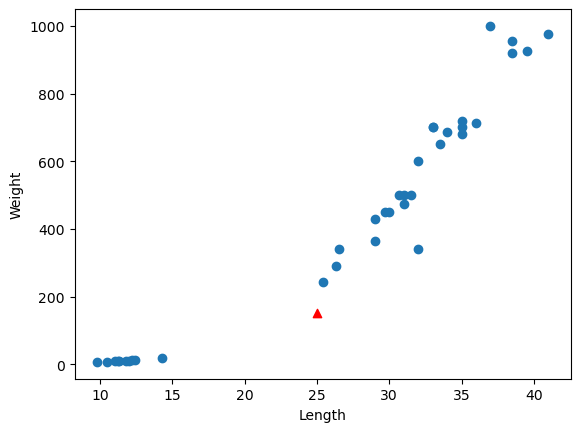

In [39]:
plt.scatter(
    train_input[:,0],
    train_input[:,1]
)
plt.scatter(
    25,
    150,
    marker="^",
    c='red'
)
plt.xlabel('Length')
plt.ylabel('Weight')
plt.show()

### 이웃을 출력해보자

In [41]:
distance, indexes = kn.kneighbors([[25, 150]])
print(indexes)

[[11 20 13 22 15]]


In [42]:
# 이웃 indexes에 해당하는 Feature를 출력
train_input[indexes]

array([[[ 25.4, 242. ],
        [ 14.3,  19.7],
        [ 12.4,  13.4],
        [ 12.2,  12.2],
        [ 26.3, 290. ]]])

In [43]:
# 이웃 indexes에 해당하는 target를 출력
train_target[indexes]

array([['apple', 'berry', 'berry', 'berry', 'apple']], dtype=object)

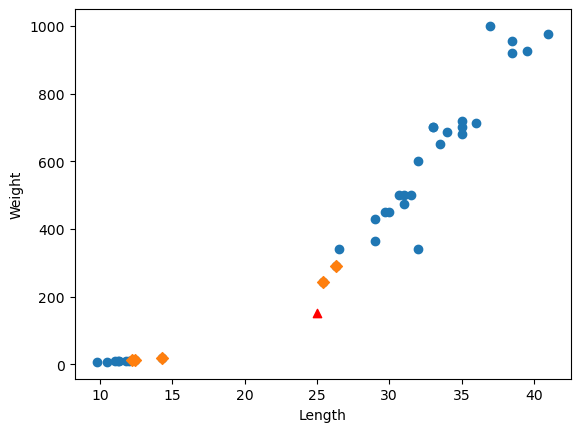

In [45]:
# 이웃의 위치를 출력
plt.scatter(
    train_input[:,0],
    train_input[:,1]
)
plt.scatter(
    25,
    150,
    marker="^",
    c='red'
)

plt.scatter(
    train_input[indexes, 0],
    train_input[indexes, 1],
    marker="D"
)

plt.xlabel('Length')
plt.ylabel('Weight')
plt.show()

---
### 기준을 맞추자

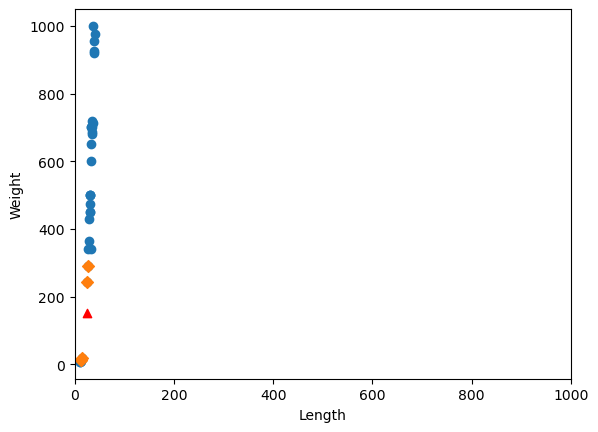

In [46]:
plt.scatter(
    train_input[:,0],
    train_input[:,1]
)
plt.scatter(
    25,
    150,
    marker="^",
    c='red'
)

plt.scatter(
    train_input[indexes, 0],
    train_input[indexes, 1],
    marker="D"
)

plt.xlim(0, 1000)
plt.xlabel('Length')
plt.ylabel('Weight')
plt.show()

> data가 Length에는 거의 영향을 받지 않고 weight에서 영향을 많이 받는다.
중요한 Feature는 Weight

In [47]:
# length와 weight의 평균과 표준편차
mean = np.mean(train_input, axis=0)
mean

array([ 26.93333333, 441.98333333])

In [48]:
std = np.std(train_input, axis=0)
std

array([ 10.09141549, 325.61300692])

#### train_data를 표준점수(z점수) 변경
표쥰점수 = (Feature - 평균) / 표준편차

In [49]:
train_scaled = (train_input - mean) / std
train_scaled[:5]

array([[ 0.79935928,  0.85382543],
       [ 0.20479453, -0.24256812],
       [-1.54917151, -1.33066961],
       [ 0.37325454,  0.17817675],
       [-1.55908092, -1.32729137]])

### sklearn을 이용

In [50]:
from sklearn.preprocessing import StandardScaler

In [51]:
scaler = StandardScaler()
scaler.fit(train_input)

,copy,True
,with_mean,True
,with_std,True


In [52]:
train_scaled2 = scaler.transform(train_input)
train_scaled2[:5]

array([[ 0.79935928,  0.85382543],
       [ 0.20479453, -0.24256812],
       [-1.54917151, -1.33066961],
       [ 0.37325454,  0.17817675],
       [-1.55908092, -1.32729137]])

In [53]:
train_scaled3 = scaler.fit_transform(train_input)
train_scaled3[:5]

array([[ 0.79935928,  0.85382543],
       [ 0.20479453, -0.24256812],
       [-1.54917151, -1.33066961],
       [ 0.37325454,  0.17817675],
       [-1.55908092, -1.32729137]])

### 전처리 데이터로 모델 훈련하기

In [54]:
# 예측할 데이터도 표준점수 변경이 필요
new = ([25, 150] - mean) / std
new

array([-0.19158198, -0.89671889])

### KNN

In [55]:
kn.fit(train_scaled3, train_target)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [56]:
test_scaled = (test_input - mean) / std


In [58]:
print(kn.score(train_scaled3, train_target))
print(kn.score(test_scaled, test_target))

1.0
1.0


In [59]:
# 예측
kn.predict([new])

array(['apple'], dtype=object)

### 시각화

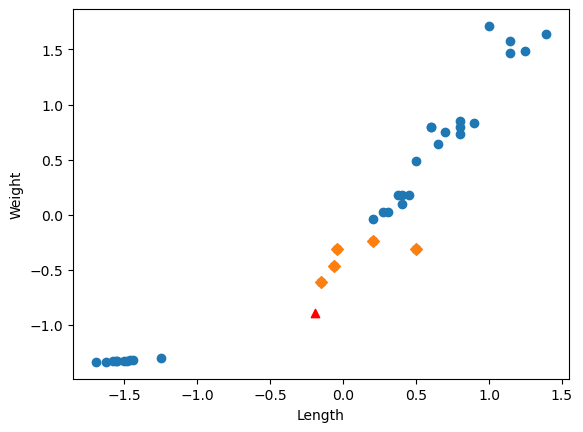

In [61]:
# 이웃의 위치를 출력
distances, indexes = kn.kneighbors([new])
plt.scatter(
    train_scaled3[:,0],
    train_scaled3[:,1]
)
plt.scatter(
    new[0],
    new[1],
    marker="^",
    c='red'
)

plt.scatter(
    train_scaled3[indexes, 0],
    train_scaled3[indexes, 1],
    marker="D"
)

plt.xlabel('Length')
plt.ylabel('Weight')
plt.show()